## 1. Import Libraries

In [3]:
# standard data stuff
import pandas as pd
import numpy as np

# for plotting
import matplotlib.pyplot as plt

# splitting data into train/test
from sklearn.model_selection import train_test_split

# scaling the features so they're on the same range
# this matters a lot for KNN and SVM
from sklearn.preprocessing import StandardScaler

# metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# the 4 classifiers i'm going to compare
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')  # hides some annoying sklearn warnings

print('Libraries loaded.')

Libraries loaded.


## 2. Load & Inspect Data

In [4]:
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
# 'id' is just a patient ID, not useful for prediction
# 'Unnamed: 32' is an empty column that comes with the dataset for some reason
df = df.drop(columns=['id'])
df = df.drop(columns=['Unnamed: 32'])

print(df.shape)

(569, 31)


In [6]:
# checking class distribution
# if one class is way bigger than the other, the model could just predict
# the majority class and still get high accuracy — so this matters
print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [7]:
# always good to check for missing values before doing anything
print(df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


## 3. Exploratory Data Analysis

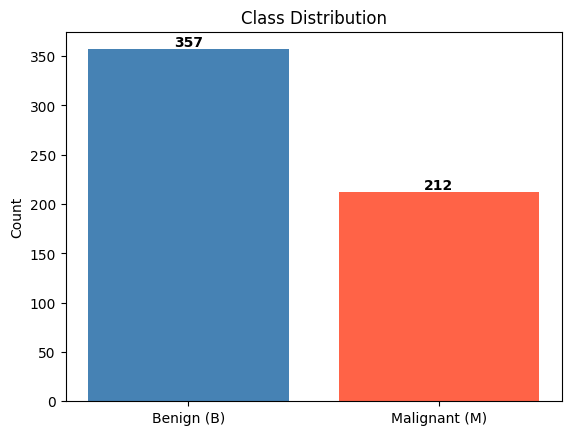

In [8]:
# visualizing class balance
benign_count = df[df['diagnosis'] == 'B'].shape[0]
malignant_count = df[df['diagnosis'] == 'M'].shape[0]

plt.bar(['Benign (B)', 'Malignant (M)'], [benign_count, malignant_count], color=['steelblue', 'tomato'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.text(0, benign_count + 3, str(benign_count), ha='center', fontweight='bold')
plt.text(1, malignant_count + 3, str(malignant_count), ha='center', fontweight='bold')
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

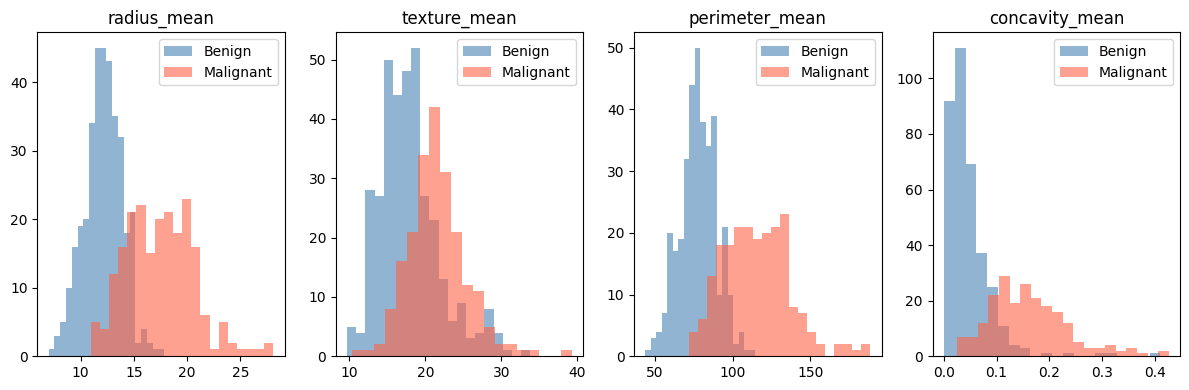

In [9]:
# looking at a few features to see if they separate M vs B
# if they overlap a lot, the model will have a harder time

benign = df[df['diagnosis'] == 'B']
malignant = df[df['diagnosis'] == 'M']

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.hist(benign['radius_mean'], alpha=0.6, color='steelblue', label='Benign', bins=20)
plt.hist(malignant['radius_mean'], alpha=0.6, color='tomato', label='Malignant', bins=20)
plt.title('radius_mean')
plt.legend()

plt.subplot(1, 4, 2)
plt.hist(benign['texture_mean'], alpha=0.6, color='steelblue', label='Benign', bins=20)
plt.hist(malignant['texture_mean'], alpha=0.6, color='tomato', label='Malignant', bins=20)
plt.title('texture_mean')
plt.legend()

plt.subplot(1, 4, 3)
plt.hist(benign['perimeter_mean'], alpha=0.6, color='steelblue', label='Benign', bins=20)
plt.hist(malignant['perimeter_mean'], alpha=0.6, color='tomato', label='Malignant', bins=20)
plt.title('perimeter_mean')
plt.legend()

plt.subplot(1, 4, 4)
plt.hist(benign['concavity_mean'], alpha=0.6, color='steelblue', label='Benign', bins=20)
plt.hist(malignant['concavity_mean'], alpha=0.6, color='tomato', label='Malignant', bins=20)
plt.title('concavity_mean')
plt.legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

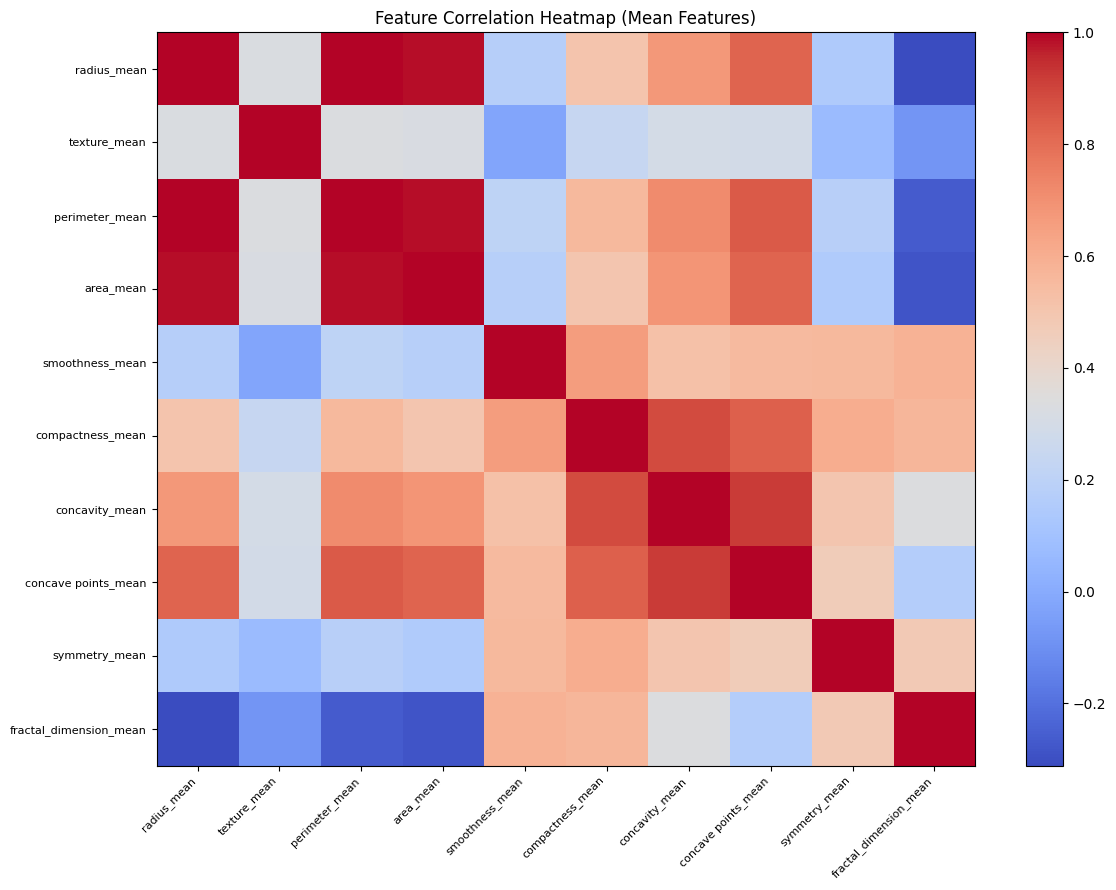

In [10]:
# correlation heatmap — want to see which features are related to each other
# features that are highly correlated basically carry the same information
# only doing the '_mean' features here to keep it readable

mean_cols = [col for col in df.columns if col.endswith('_mean')]
corr_matrix = df[mean_cols].corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(mean_cols)), mean_cols, rotation=45, ha='right', fontsize=8)
plt.yticks(range(len(mean_cols)), mean_cols, fontsize=8)
plt.title('Feature Correlation Heatmap (Mean Features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing

In [11]:
# converting M/B to 1/0 so sklearn can work with it
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(columns=['diagnosis'])  # all features
y = df['diagnosis']                 # what we're trying to predict

print(X.shape)
print(y.value_counts())

(569, 30)
diagnosis
0    357
1    212
Name: count, dtype: int64


In [12]:
# using stratify=y so the train and test sets have the same class ratio
# without this, by chance we could get a test set that's mostly one class
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print('Training samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Training samples: 455
Test samples: 114


In [13]:
# scaling is really important for KNN and SVM because they use distances
# if one feature is in the thousands and another is 0-1, the big one dominates
# fit only on training data — never on test data (that would be data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # just transform, don't fit again

## 5. Train & Compare Models

In [14]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression')
print('Accuracy: ', round(accuracy_score(y_test, lr_pred), 4))
print('Precision:', round(precision_score(y_test, lr_pred), 4))
print('Recall:   ', round(recall_score(y_test, lr_pred), 4))
print('F1 Score: ', round(f1_score(y_test, lr_pred), 4))
print('AUC:      ', round(roc_auc_score(y_test, lr_prob), 4))

Logistic Regression
Accuracy:  0.9649
Precision: 0.975
Recall:    0.9286
F1 Score:  0.9512
AUC:       0.996


In [15]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

print('Random Forest')
print('Accuracy: ', round(accuracy_score(y_test, rf_pred), 4))
print('Precision:', round(precision_score(y_test, rf_pred), 4))
print('Recall:   ', round(recall_score(y_test, rf_pred), 4))
print('F1 Score: ', round(f1_score(y_test, rf_pred), 4))
print('AUC:      ', round(roc_auc_score(y_test, rf_prob), 4))

Random Forest
Accuracy:  0.9737
Precision: 1.0
Recall:    0.9286
F1 Score:  0.963
AUC:       0.9929


In [16]:
# --- K-Nearest Neighbors ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_prob = knn.predict_proba(X_test_scaled)[:, 1]

print('K-Nearest Neighbors')
print('Accuracy: ', round(accuracy_score(y_test, knn_pred), 4))
print('Precision:', round(precision_score(y_test, knn_pred), 4))
print('Recall:   ', round(recall_score(y_test, knn_pred), 4))
print('F1 Score: ', round(f1_score(y_test, knn_pred), 4))
print('AUC:      ', round(roc_auc_score(y_test, knn_prob), 4))

K-Nearest Neighbors
Accuracy:  0.9561
Precision: 0.9744
Recall:    0.9048
F1 Score:  0.9383
AUC:       0.9823


In [17]:
# --- Support Vector Machine ---
# probability=True is needed so we can calculate AUC later
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

print('Support Vector Machine')
print('Accuracy: ', round(accuracy_score(y_test, svm_pred), 4))
print('Precision:', round(precision_score(y_test, svm_pred), 4))
print('Recall:   ', round(recall_score(y_test, svm_pred), 4))
print('F1 Score: ', round(f1_score(y_test, svm_pred), 4))
print('AUC:      ', round(roc_auc_score(y_test, svm_prob), 4))

Support Vector Machine
Accuracy:  0.9737
Precision: 1.0
Recall:    0.9286
F1 Score:  0.963
AUC:       0.9947


In [18]:
# putting results in a table to compare side by side
results = {
    'Model':     ['Logistic Regression', 'Random Forest', 'K-Nearest Neighbors', 'Support Vector Machine'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),  accuracy_score(y_test, rf_pred),  accuracy_score(y_test, knn_pred),  accuracy_score(y_test, svm_pred)],
    'Precision': [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred), precision_score(y_test, knn_pred), precision_score(y_test, svm_pred)],
    'Recall':    [recall_score(y_test, lr_pred),    recall_score(y_test, rf_pred),    recall_score(y_test, knn_pred),    recall_score(y_test, svm_pred)],
    # recall is the most important metric here — missing a malignant tumor
    # (false negative) is way worse than a false alarm (false positive)
    'F1 Score':  [f1_score(y_test, lr_pred),        f1_score(y_test, rf_pred),        f1_score(y_test, knn_pred),        f1_score(y_test, svm_pred)],
    'AUC':       [roc_auc_score(y_test, lr_prob),   roc_auc_score(y_test, rf_prob),   roc_auc_score(y_test, knn_prob),   roc_auc_score(y_test, svm_prob)]
}

results_df = pd.DataFrame(results).set_index('Model').round(4)
print(results_df.to_string())

                        Accuracy  Precision  Recall  F1 Score     AUC
Model                                                                
Logistic Regression       0.9649     0.9750  0.9286    0.9512  0.9960
Random Forest             0.9737     1.0000  0.9286    0.9630  0.9929
K-Nearest Neighbors       0.9561     0.9744  0.9048    0.9383  0.9823
Support Vector Machine    0.9737     1.0000  0.9286    0.9630  0.9947


## 6. Results Visualization

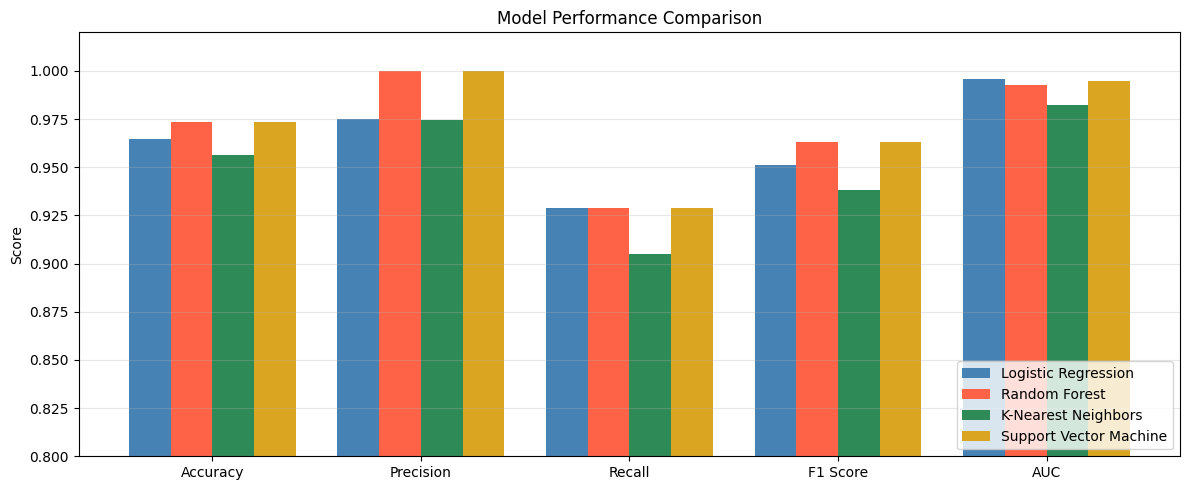

In [19]:
# bar chart to compare all models across all metrics at once
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))

lr_vals =  [results_df.loc['Logistic Regression', m]    for m in metrics]
rf_vals =  [results_df.loc['Random Forest', m]          for m in metrics]
knn_vals = [results_df.loc['K-Nearest Neighbors', m]    for m in metrics]
svm_vals = [results_df.loc['Support Vector Machine', m] for m in metrics]

ax.bar(x + 0 * width, lr_vals,  width, label='Logistic Regression',    color='steelblue')
ax.bar(x + 1 * width, rf_vals,  width, label='Random Forest',          color='tomato')
ax.bar(x + 2 * width, knn_vals, width, label='K-Nearest Neighbors',    color='seagreen')
ax.bar(x + 3 * width, svm_vals, width, label='Support Vector Machine', color='goldenrod')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)  # zooming in so differences are visible
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

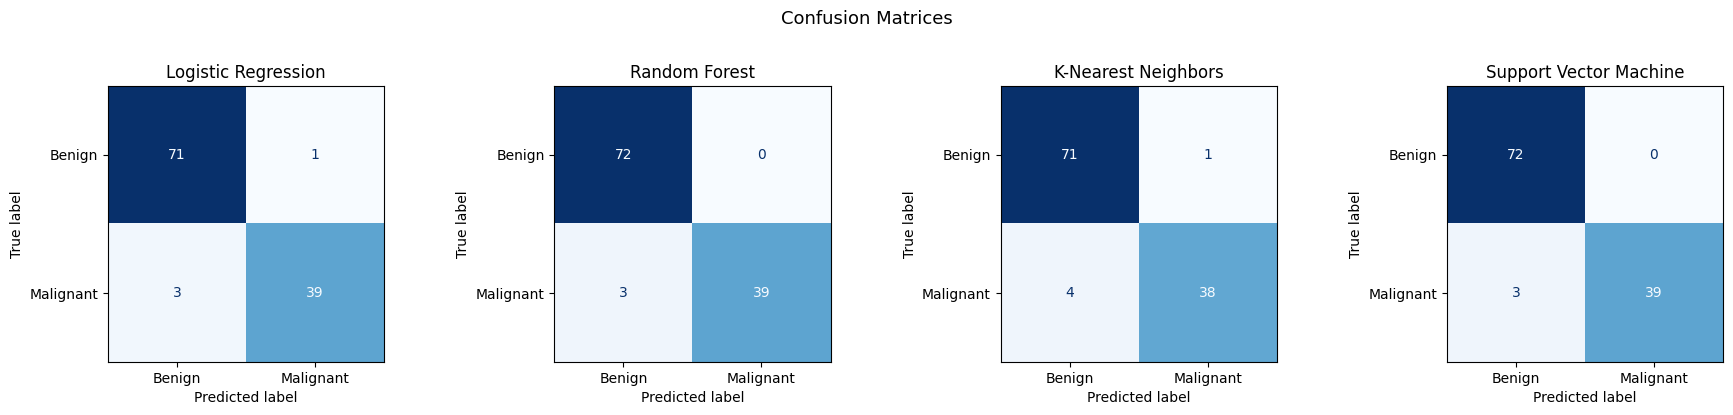

In [20]:
# confusion matrix shows exactly what the model got right and wrong
# top-left = correctly predicted benign (true negative)
# bottom-right = correctly predicted malignant (true positive)
# bottom-left = predicted benign but was actually malignant (false negative — the dangerous one)
# top-right = predicted malignant but was actually benign (false positive)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=['Benign', 'Malignant']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression')

cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['Benign', 'Malignant']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Random Forest')

cm_knn = confusion_matrix(y_test, knn_pred)
ConfusionMatrixDisplay(cm_knn, display_labels=['Benign', 'Malignant']).plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('K-Nearest Neighbors')

cm_svm = confusion_matrix(y_test, svm_pred)
ConfusionMatrixDisplay(cm_svm, display_labels=['Benign', 'Malignant']).plot(ax=axes[3], colorbar=False, cmap='Blues')
axes[3].set_title('Support Vector Machine')

plt.suptitle('Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

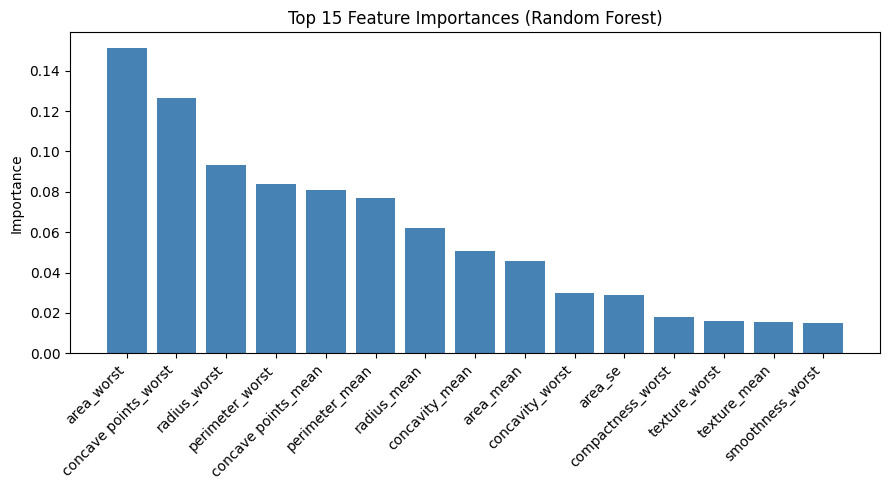

In [21]:
# random forest lets you see which features it found most useful
# this is helpful for understanding what actually matters in the data
# logistic regression and SVM don't give you this as easily

importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)
top15 = importance_df.head(15)

plt.figure(figsize=(9, 5))
plt.bar(top15['feature'], top15['importance'], color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusion

Four classifiers were trained and evaluated on the Wisconsin Breast Cancer Dataset using all 30 available tumor features.

Key findings:
- All four models achieved high accuracy (>93%) on the held-out test set
- **Recall** is the most clinically important metric here — a false negative (predicting benign when malignant) is far more dangerous than a false positive
- Feature importance analysis shows that `concave points_worst`, `perimeter_worst`, and `radius_worst` are the strongest predictors of malignancy

**Next steps:**
- Cross-validation for more robust evaluation
- Hyperparameter tuning (GridSearchCV)
- Explore dimensionality reduction (PCA) to reduce correlated features